In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
df = pd.read_excel('imdb_scrapper.xlsx')

In [4]:
print(df.shape)
print(df.info())
print(df.head())

(301, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                301 non-null    int64  
 1   Title               301 non-null    object 
 2   Genre               301 non-null    object 
 3   Description         301 non-null    object 
 4   Director            301 non-null    object 
 5   Actors              301 non-null    object 
 6   Year                301 non-null    int64  
 7   Runtime (Minutes)   301 non-null    int64  
 8   Rating              301 non-null    float64
 9   Votes               301 non-null    int64  
 10  Revenue (Millions)  271 non-null    float64
 11  Metascore           284 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 28.3+ KB
None
   Rank                    Title                     Genre  \
0     1  Guardians of the Galaxy   Action,Adventure,Sci-Fi   
1     2

In [5]:
print(df.isnull().sum())

Rank                   0
Title                  0
Genre                  0
Description            0
Director               0
Actors                 0
Year                   0
Runtime (Minutes)      0
Rating                 0
Votes                  0
Revenue (Millions)    30
Metascore             17
dtype: int64


In [6]:
df.dropna(inplace=True)


In [7]:
df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median())
df['Metascore'] = df['Metascore'].fillna(df['Metascore'].median())

In [8]:
df['Year'] = df['Year'].astype(int)
df['Runtime (Minutes)'] = df['Runtime (Minutes)'].astype(int)

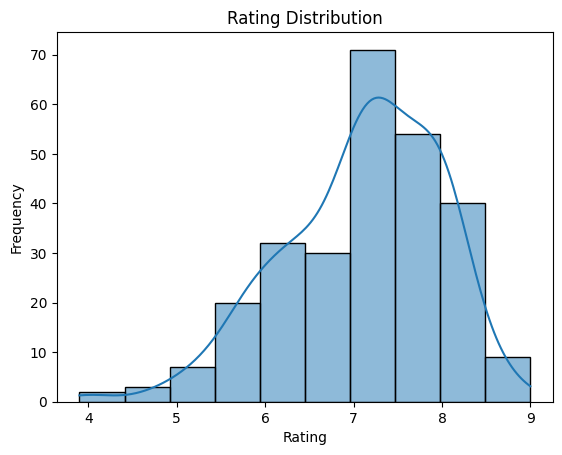

In [9]:
sns.histplot(df['Rating'], bins=10, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


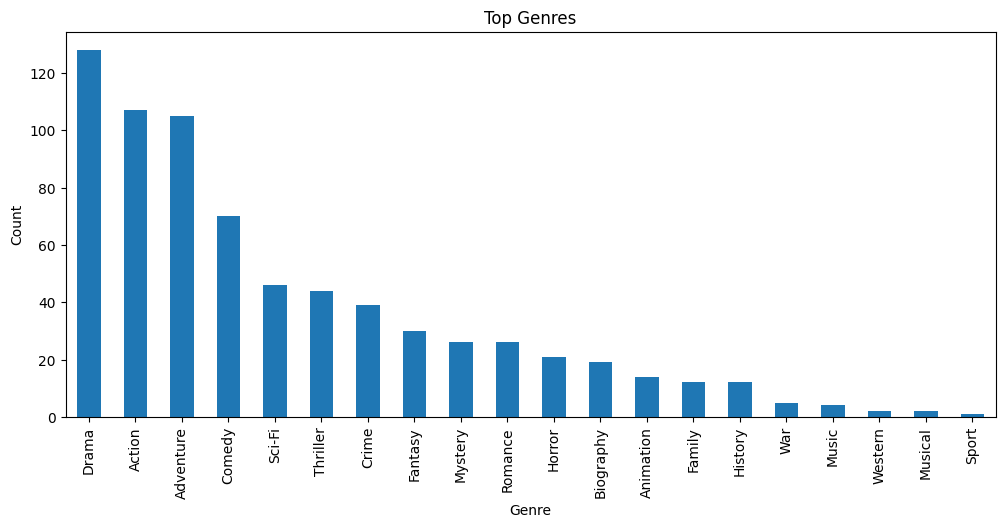

In [10]:
df['Genre'].str.split(',').explode().value_counts().plot(kind='bar', figsize=(12, 5), title="Top Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


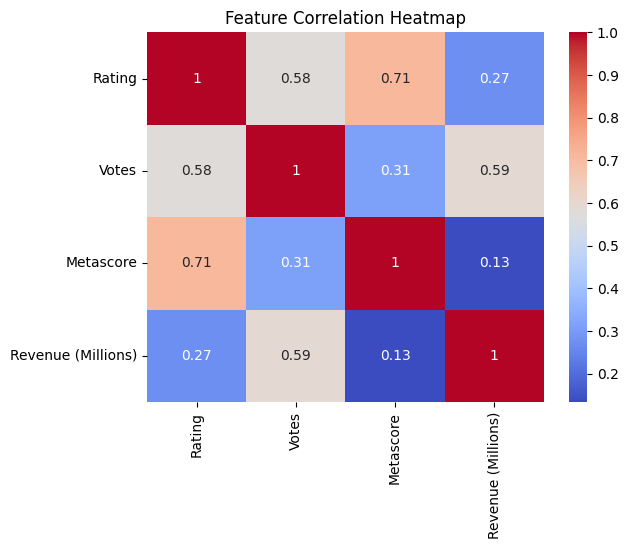

In [11]:
sns.heatmap(df[['Rating', 'Votes', 'Metascore', 'Revenue (Millions)']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


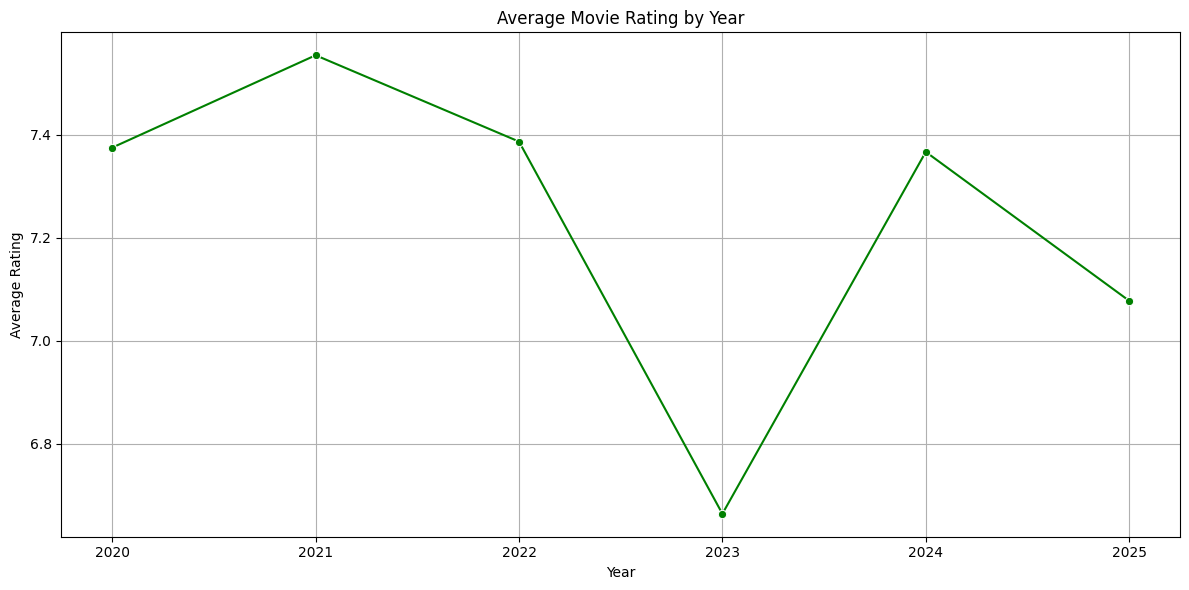

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('imdb_scrapper.xlsx')
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)
def ratings_over_time(df):
    year_rating = df.groupby('Year')['Rating'].mean().reset_index()

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=year_rating, x='Year', y='Rating', marker='o', color='green')
    plt.title("Average Movie Rating by Year")
    plt.ylabel("Average Rating")
    plt.xlabel("Year")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
ratings_over_time(df)


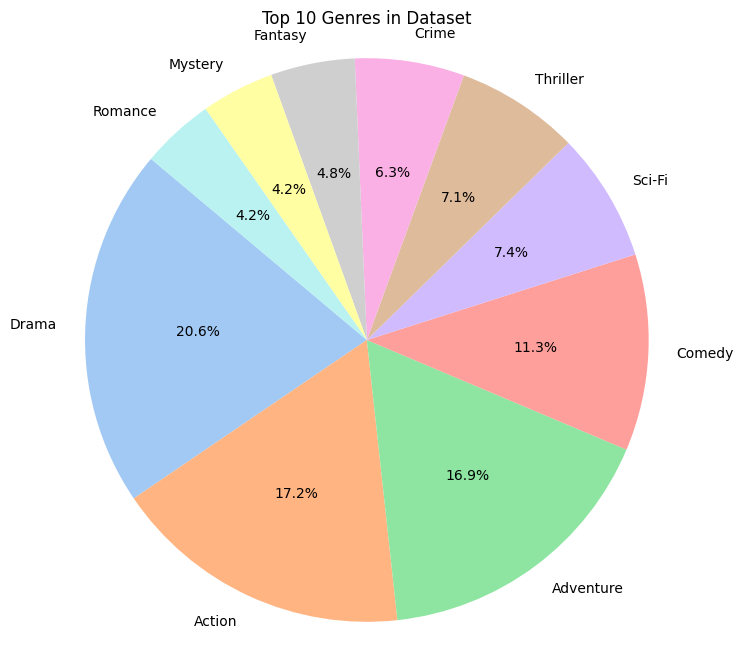

In [13]:
def genre_pie_chart():
    genre_series = df['Genre'].dropna().str.split(',').explode().str.strip()
    genre_counts = genre_series.value_counts().head(10) 

    plt.figure(figsize=(8, 8))
    plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title("Top 10 Genres in Dataset")
    plt.axis('equal')
    plt.show()

genre_pie_chart()


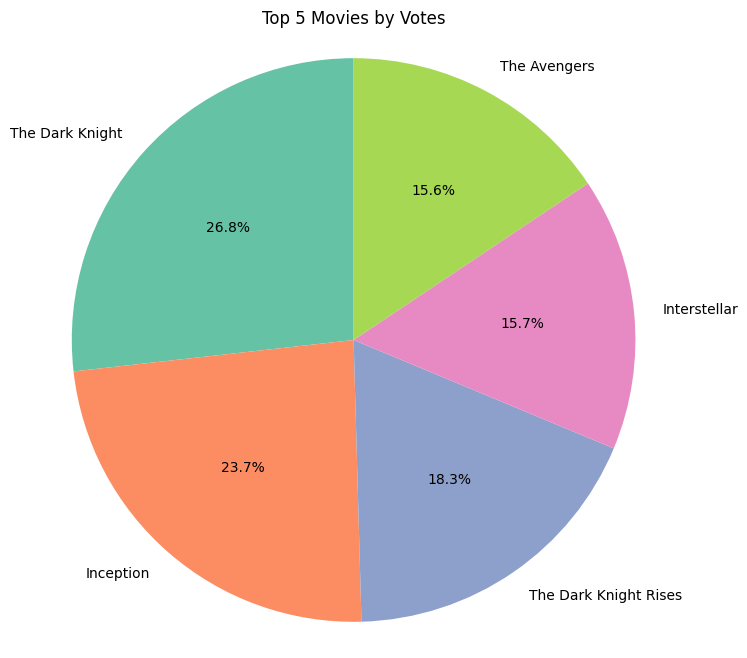

In [14]:
def vote_pie_chart():
    top_movies = df.sort_values(by='Votes', ascending=False).head(5)

    plt.figure(figsize=(8, 8))
    plt.pie(top_movies['Votes'], labels=top_movies['Title'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
    plt.title("Top 5 Movies by Votes")
    plt.axis('equal')
    plt.show()

vote_pie_chart()


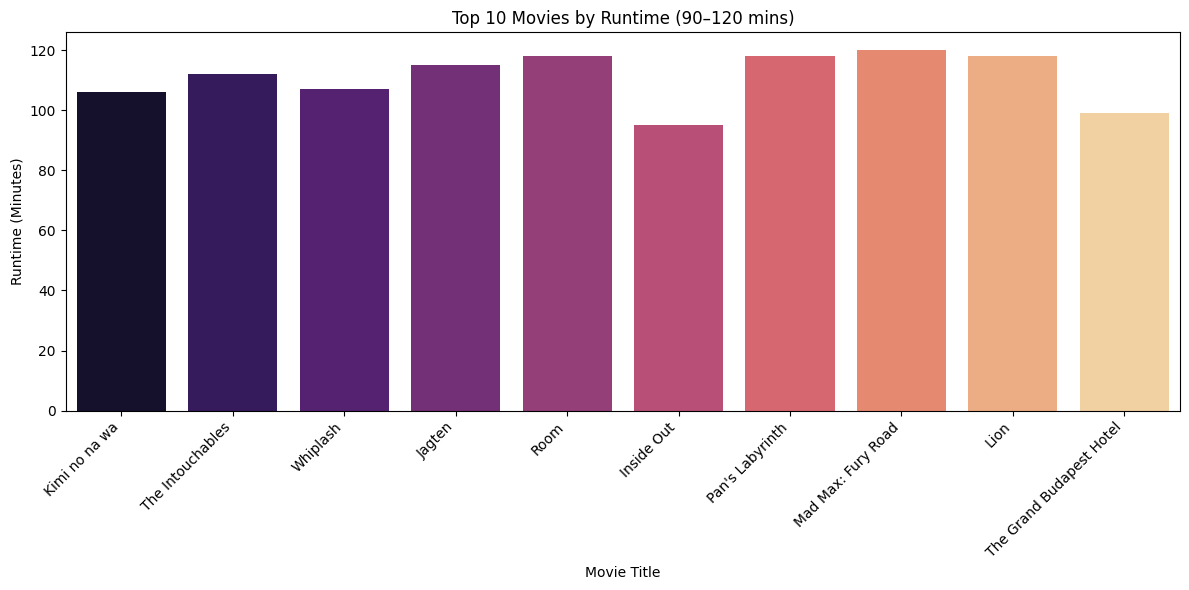

,Title,Runtime (Minutes),Rating
96,Kimi no na wa,106,8.6
249,The Intouchables,112,8.6
133,Whiplash,107,8.5
300,Jagten,115,8.3
143,Room,118,8.2
241,Inside Out,95,8.2
230,Pan's Labyrinth,118,8.2
67,Mad Max: Fury Road,120,8.1
18,Lion,118,8.1
238,The Grand Budapest Hotel,99,8.1


In [24]:
def recommend_by_runtime(min_time=90, max_time=120):
    filtered = df[(df['Runtime (Minutes)'] >= min_time) & (df['Runtime (Minutes)'] <= max_time)]
    top_movies = filtered.sort_values(by='Rating', ascending=False)[['Title', 'Runtime (Minutes)', 'Rating']].head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_movies, x='Title', y='Runtime (Minutes)', hue='Title', palette='magma', legend=False)
    plt.xticks(rotation=45, ha='right')
    plt.title('Top 10 Movies by Runtime (90–120 mins)')
    plt.ylabel('Runtime (Minutes)')
    plt.xlabel('Movie Title')
    plt.tight_layout()
    plt.show()
    return top_movies

recommend_by_runtime()

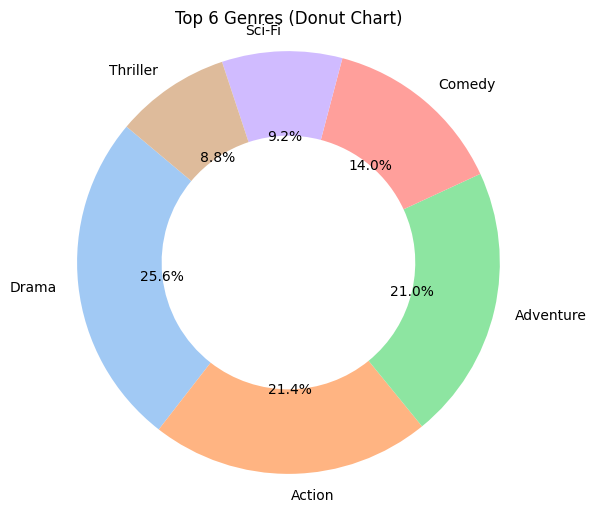

In [21]:
genre_counts = df['Genre'].str.split(',').explode().str.strip().value_counts().head(6)

plt.figure(figsize=(6, 6))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, wedgeprops={'width': 0.4}, colors=sns.color_palette("pastel"))
plt.title("Top 6 Genres (Donut Chart)")
plt.axis('equal')
plt.show()